# TPI 1: Adquisición y Análisis Lingüístico de Medios

**Modalidad:** Trabajo Práctico Individual (calificación numérica de 0 a 10).

**Fecha de entrega y exposición:** Jueves 16 de abril. Se realizará de manera expositiva en remoto frente a todo el grupo de estudiantes (aproximadamente 10 minutos por presentación) para que entre quienes participan veamos posibles soluciones.

**Duración estimada de codificación:** 2 horas

**Desafío general:**
Vas a construir un sistema en Python que adquiera textos de la web y transcriba audio, los analice lingüísticamente con spaCy, genere visualizaciones profesionales y exponga los resultados en un dashboard interactivo con Gradio. Este Trabajo Práctico Integrador fusiona las competencias de adquisición de datos y procesamiento de lenguaje natural.

**Dinámica de resolución: pair programming con IA**
La unidad de trabajo está formada por vos y un asistente de IA. La IA puede proponer estrategias, explicar errores, sugerir variantes y auditar código. No reemplaza tu pensamiento ni tu criterio. Toda decisión final, toda justificación y toda versión entregada tienen que estar bajo tu responsabilidad.

---

### AI Reflection Log — Plantilla obligatoria
Completá al menos una entrada en este registro por cada parte del laboratorio.

| Parte | Objetivo de la consulta | Prompt o pedido a la IA | Qué responidó (resumen) | Qué conservaste y por qué | Qué descartaste y por qué | Qué aprendiste |
|---|---|---|---|---|---|---|
| **Parte 1** | | | | | | |
| **Parte 2** | | | | | | |
| **Parte 3** | | | | | | |
| **Parte 4** | | | | | | |
| **Parte 5** | | | | | | |

In [88]:
# PASO 0: Instalación de las librerías necesarias
# Ejecutá esta celda una sola vez.
!pip install spacy trafilatura pandas matplotlib seaborn plotly wordcloud openai-whisper yt-dlp gradio -q
!python -m spacy download es_core_news_lg -q


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_lg')



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [89]:
import spacy
import pandas as pd
import trafilatura
import whisper
import json
import gradio as gr
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from collections import Counter
from wordcloud import WordCloud
import os

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


## Parte 1: Adquisición Multimodal del Corpus

**Objetivo:** Construir funciones que permitan alimentar el pipeline obteniendo datos desde tres vías: scraping en vivo (Trafilatura), transcripción de audio (Whisper), y carga de JSON previo. Luego, unificarlas en un único DataFrame.

> [!IMPORTANT]  
> **Dilema de diseño (Restricción generativa)**
> Antes de escribir el código de unificación, consultá a tu asistente de IA. Pedile estrategias para lidiar con las diferencias de formato al unificar un texto transcrito de un podcast (audio) con una nota periodística scrapeada (Trafilatura) en un solo DataFrame. 
> Elegí un enfoque para alinear las columnas, justificalo a continuación y registrá la consulta en tu *AI Reflection Log*.

**Escribí tu justificación acá:**
(*Defini una estructura común para organizar los datos provenientes de distintas fuentes (web, audio y JSON). Esta estructura incluye las columnas: fuente, fecha_extraccion, fecha_publicacion, tipo, titulo, texto y origen. De esta manera, todos los datos pueden almacenarse en un mismo formato, facilitando su integración en un único DataFrame para su posterior análisis.En los casos donde alguna fuente no proporcione ciertos campos, se completarán con valores nulos *) 

In [14]:
# 1.1 Scraping en vivo
from datetime import datetime
import trafilatura

def extraer_noticias_web(urls):
    noticias = []

    for url in urls:
        try:
            descargado = trafilatura.fetch_url(url)
            if not descargado:
                print(f"No se pudo obtener la URL: {url}")
                continue

            texto = trafilatura.extract(
                descargado,
                include_comments=False,
                include_images=False
            )

            if not texto:
                print(f"No se pudo extraer texto de la URL: {url}")
                continue

            registro = {
                "fuente": "web",
                "fecha_extraccion": datetime.now().strftime("%Y-%m-%d"),
                "fecha_publicacion": None,
                "tipo": "noticia",
                "titulo": None,
                "texto": texto,
                "origen": url
            }

            noticias.append(registro)

        except Exception as e:
            print(f"Error al procesar {url}: {e}")

    return noticias

In [15]:
urls = ["https://www.bbc.com/mundo","https://elpais.com",
    "https://www.infobae.com",
    "https://www.perfil.com",
    "https://www.clarin.com"]

resultado = extraer_noticias_web(urls)
print(resultado)


[{'fuente': 'web', 'fecha_extraccion': '2026-04-10', 'fecha_publicacion': None, 'tipo': 'noticia', 'titulo': None, 'texto': 'BBC News, Mundo - Página de inicio\nPrincipales\nLa tripulación de Artemis II completa la peligrosa maniobra de reingreso a la Tierra y ameriza en el Pacífico\nLos cuatro astronautas a bordo de la nave espacial Orión completaron con éxito su retorno a la Tierra, luego de una travesía de 10 días en el Espacio Exterior.\n"Montados en una bola de fuego": cómo regresó a la Tierra la tripulación de la histórica misión Artemis II a la Luna\nLos cuatro astronautas a bordo de la nave espacial Orión amerizaron frente a la costa de San Diego, en California.\n"Más eficaz que la capacidad nuclear": cómo Irán descubrió que el estrecho de Ormuz es su arma más potente en la guerra con EE.UU. e Israel\nEn la guerra con EE.UU. e Israel, Irán ha constatado que controlar este pasaje marítimo podría reportarle una mayor ventaja estratégica que una escalada militar convencional.\nPor

In [16]:
df_web = pd.DataFrame(resultado)
df_web

,fuente,fecha_extraccion,fecha_publicacion,tipo,titulo,texto,origen
0,web,2026-04-10,None,noticia,None,"BBC News, Mundo - Página de inicio\nPrincipale...",https://www.bbc.com/mundo
1,web,2026-04-10,None,noticia,None,Los astronautas de Artemis 2 aterrizan y concl...,https://elpais.com
2,web,2026-04-10,None,noticia,None,"10 Abr, 2026\nEscuchar radio Online\nPor Vícto...",https://www.infobae.com
3,web,2026-04-10,None,noticia,None,Artemis II volvió a la Tierra: el regreso de l...,https://www.perfil.com
4,web,2026-04-10,None,noticia,None,"Tras 10 días en el espacio, concluyó con éxito...",https://www.clarin.com


In [90]:
import os
from datetime import datetime

import yt_dlp
import whisper
import pandas as pd

In [91]:
_MODELOS_WHISPER = {}

In [92]:
def transcribir_audio_youtube(url_video):
    """Descarga audio de YouTube y lo transcribe"""

    try:
        carpeta_audios = "audios"
        os.makedirs(carpeta_audios, exist_ok=True)

        opciones = {
            "format": "bestaudio/best",
            "noplaylist": True,
            "outtmpl": os.path.join(carpeta_audios, "audio.%(ext)s"),
            "quiet": True
        }

        # Descargar + metadata
        with yt_dlp.YoutubeDL(opciones) as ydl:
            info = ydl.extract_info(url_video, download=True)

        titulo = info.get("title")
        fecha_publicacion = info.get("upload_date")

        # Buscar archivo descargado
        archivo_audio = None
        for archivo in os.listdir(carpeta_audios):
            if archivo.startswith("audio"):
                archivo_audio = os.path.join(carpeta_audios, archivo)
                break

        if archivo_audio is None:
            print("No se encontró el audio")
            return []

        # Cargar Whisper (solo una vez)
        if "base" not in _MODELOS_WHISPER:
            _MODELOS_WHISPER["base"] = whisper.load_model("base")

        modelo = _MODELOS_WHISPER["base"]

        resultado = modelo.transcribe(archivo_audio, language="es", fp16=False)

        # Registro tipo TP
        registro_audio = {
            "fuente": "audio",
            "fecha_extraccion": datetime.now().strftime("%Y-%m-%d"),
            "fecha_publicacion": fecha_publicacion,
            "tipo": "transcripcion",
            "titulo": titulo,
            "texto": resultado["text"],
            "origen": url_video
        }

        return [registro_audio]

    except Exception as e:
        print(f"Error: {e}")
        return []

In [31]:
url_video = "https://www.youtube.com/watch?v=aqz-KE-bpKQ"

datos_audio = transcribir_audio_youtube(url_video)

In [32]:
df_audio = pd.DataFrame(datos_audio)
df_audio.head()

,fuente,fecha_extraccion,fecha_publicacion,tipo,titulo,texto,origen
0,audio,2026-04-11,20141110,transcripcion,Big Buck Bunny 60fps 4K - Official Blender Fou...,"Nope. Liste, perdón. Ooooka Ho!' Es lo mira, ...",https://www.youtube.com/watch?v=aqz-KE-bpKQ


In [93]:
# 1.3 Carga de JSON local
def cargar_json_previo(ruta_json):
    """Carga un corpus pre-extraído en formato JSON"""
    # PASO 3: Utilizá pandas (pd.read_json) o la librería json nativa para cargar los datos.
    
    return []

In [44]:
import json
import trafilatura
from datetime import datetime

# 1. URL de Wikipedia
url = "https://es.wikipedia.org/wiki/Procesamiento_de_lenguaje_natural"

# 2. Descargar HTML
html = trafilatura.fetch_url(url)

if not html:
    print("❌ No se pudo descargar la página")

else:
    # 3. Extraer texto
    texto = trafilatura.extract(html)

    if not texto:
        print("❌ No se pudo extraer el contenido")

    else:
        # 4. Crear estructura tipo corpus
        datos = [{
            "fuente": "json",
            "fecha_extraccion": datetime.now().strftime("%Y-%m-%d"),
            "fecha_publicacion": None,
            "tipo": "articulo",
            "titulo": "Procesamiento de Lenguaje Natural",
            "texto": texto,
            "origen": url
        }]

        # 5. Guardar JSON
        with open("wikipedia_pln.json", "w", encoding="utf-8") as f:
            json.dump(datos, f, ensure_ascii=False, indent=2)

        print("✅ JSON creado correctamente: wikipedia_pln.json")

✅ JSON creado correctamente: wikipedia_pln.json


In [45]:
import json

def cargar_json_previo(ruta_json):
    with open(ruta_json, "r", encoding="utf-8") as f:
        datos = json.load(f)
    return datos

datos_json = cargar_json_previo("wikipedia_pln.json")

print(datos_json[:1])

[{'fuente': 'json', 'fecha_extraccion': '2026-04-11', 'fecha_publicacion': None, 'tipo': 'articulo', 'titulo': 'Procesamiento de Lenguaje Natural', 'texto': 'Procesamiento de lenguajes naturales\nEl procesamiento de(l) lenguaje natural o de lengua(je)s naturales,[1][2] abreviado PLN[3][4] (o NLP por sus siglas en inglés), es un campo de las ciencias de la computación, de la inteligencia artificial y de la lingüística que estudia las interacciones entre las computadoras y el lenguaje humano, así como los detalles computacionales de las lenguas naturales. Se ocupa de la formulación e investigación de mecanismos eficaces computacionalmente para la comunicación entre personas y máquinas por medio del lenguaje natural, es decir, de las lenguas del mundo. No trata de la comunicación por medio de lenguas naturales de una forma abstracta, sino de diseñar mecanismos para comunicarse que sean eficaces computacionalmente —que se puedan realizar por medio de programas que ejecuten o simulen la com

In [46]:
df_json = pd.DataFrame(datos_json)
df_json.head()

,fuente,fecha_extraccion,fecha_publicacion,tipo,titulo,texto,origen
0,json,2026-04-11,None,articulo,Procesamiento de Lenguaje Natural,Procesamiento de lenguajes naturales\nEl proce...,https://es.wikipedia.org/wiki/Procesamiento_de...


In [47]:
# 1.4 Consolidación
def unificar_corpus(datos_web, datos_audio, datos_json):
    """Unifica las tres fuentes en un DataFrame con columnas estándar"""
    # PASO 4: Implementá la estrategia que decidiste en el dilema de diseño.
    # El DataFrame final debería tener al menos: 'titulo_o_fuente', 'texto', 'origen' ('web', 'audio', 'json')
    
    df_unificado = pd.DataFrame()
    return df_unificado

# ---- Espacio para pruebas ----
# Probá tus funciones acá con al menos 1 url web y 1 video corto.
# df_corpus = unificar_corpus(...)

In [48]:
# 1.4 Consolidación
def unificar_corpus(datos_web, datos_audio, datos_json):
    """Unifica las tres fuentes en un DataFrame con columnas estándar"""

    import pandas as pd

    # 1) Juntamos todos los registros en una sola lista
    corpus_data = []

    if datos_web:
        corpus_data.extend(datos_web)

    if datos_audio:
        corpus_data.extend(datos_audio)

    if datos_json:
        corpus_data.extend(datos_json)

    # 2) Convertimos a DataFrame
    df_unificado = pd.DataFrame(corpus_data)

    # 3) Aseguramos las columnas estándar del TP
    columnas_estandar = [
        "fuente",
        "fecha_extraccion",
        "fecha_publicacion",
        "tipo",
        "titulo",
        "texto",
        "origen"
    ]

    for col in columnas_estandar:
        if col not in df_unificado.columns:
            df_unificado[col] = None

    # 4) Reordenamos columnas
    df_unificado = df_unificado[columnas_estandar]

    return df_unificado

In [50]:
datos_web = extraer_noticias_web(urls)

print(len(datos_web))

5


In [51]:
df_corpus = unificar_corpus(datos_web, datos_audio, datos_json)
df_corpus.head()

,fuente,fecha_extraccion,fecha_publicacion,tipo,titulo,texto,origen
0,web,2026-04-11,NaN,noticia,NaN,"BBC News, Mundo - Página de inicio\nPrincipale...",https://www.bbc.com/mundo
1,web,2026-04-11,NaN,noticia,NaN,Los astronautas de Artemis 2 aterrizan y concl...,https://elpais.com
2,web,2026-04-11,NaN,noticia,NaN,"11 Abr, 2026\nEscuchar radio Online\nPor Vícto...",https://www.infobae.com
3,web,2026-04-11,NaN,noticia,NaN,Artemis II volvió a la Tierra: el regreso a la...,https://www.perfil.com
4,web,2026-04-11,NaN,noticia,NaN,"Tras 10 días en el espacio, concluyó con éxito...",https://www.clarin.com


In [52]:
df_corpus["fuente"].value_counts()

fuente
web      5
audio    1
json     1
Name: count, dtype: int64

In [53]:
datos_json = cargar_json_previo("wikipedia_pln.json")

df_corpus = unificar_corpus(datos_web, datos_audio, datos_json)

df_corpus.head()

,fuente,fecha_extraccion,fecha_publicacion,tipo,titulo,texto,origen
0,web,2026-04-11,NaN,noticia,NaN,"BBC News, Mundo - Página de inicio\nPrincipale...",https://www.bbc.com/mundo
1,web,2026-04-11,NaN,noticia,NaN,Los astronautas de Artemis 2 aterrizan y concl...,https://elpais.com
2,web,2026-04-11,NaN,noticia,NaN,"11 Abr, 2026\nEscuchar radio Online\nPor Vícto...",https://www.infobae.com
3,web,2026-04-11,NaN,noticia,NaN,Artemis II volvió a la Tierra: el regreso a la...,https://www.perfil.com
4,web,2026-04-11,NaN,noticia,NaN,"Tras 10 días en el espacio, concluyó con éxito...",https://www.clarin.com


> **Pausa de auditoría:**
> Revisá tu DataFrame consolidado (`df_corpus.head()`). ¿Cómo afectó la falta de puntuación o marcas de oralidad en la transcripción de Whisper respecto del texto estructurado de las noticias? Revisá las columnas generadas. ¿Perdiste información contextual al unificarlas?

## Parte 2: Análisis Lingüístico con spaCy

**Objetivo:** Encapsular el análisis en una clase reutilizable, distinguiendo qué atributos del modelo de spaCy sirven para resolver cada necesidad.

> [!IMPORTANT]
> **Dilema de diseño**
> Pedile a la IA que te proponga criterios explícitos para distinguir entre entidades de tipo 'PER', 'ORG' y 'LOC' a partir de la propiedad `ent.label_` de spaCy. Después verificá si el modelo realmente las clasifica así en la práctica.
> Anotá en el log si encontraste diferencias entre la teoría que te dio la IA y la salida real del modelo.

In [86]:
class AnalizadorCorpus:
    def __init__(self, df, modelo_spacy="es_core_news_lg"):
        self.df = df
        print("Cargando modelo de lenguaje...")
        self.nlp = spacy.load(modelo_spacy)
        
        # Procesamos la columna 'texto' al instanciar la clase
        print("Procesando los textos con spaCy...")
        self.df["doc"] = self.df["texto"].fillna("").apply(self.nlp)
    def extraer_entidades(self):
        from collections import Counter

        entidades = []

        for doc in self.df["doc"]:
            for ent in doc.ents:
                entidades.append((ent.text, ent.label_))

        conteo = Counter(entidades)

        resultado = []
        for (texto, tipo), frecuencia in conteo.items():
            resultado.append({
            "entidad": texto,
            "tipo": tipo,
            "frecuencia": frecuencia
        })

        return resultado
    def extraer_verbos_principales(self, n=15):
        from collections import Counter

        verbos = []

        for doc in self.df["doc"]:
            for token in doc:
                if token.pos_ == "VERB" and not token.is_stop and not token.is_punct:
                    verbos.append(token.lemma_.lower())

        return Counter(verbos).most_common(n)

    def extraer_palabras_clave(self, n=20):
        """Devuelve sustantivos y nombres propios lematizados y filtrados"""
        # PASO 4: Implementá una lógica superior a la del Lab 009 (donde usamos stopwords crudas).
        # Filtrá por categorías gramaticales relevantes (NOUN, PROPN, ADJ) omitiendo puntuación y stopwords.

   
        from collections import Counter

        palabras = []

        for doc in self.df["doc"]:
            for token in doc:
                if token.pos_ in ["NOUN", "PROPN", "ADJ"] \
                    and not token.is_stop \
                    and not token.is_punct \
                    and not token.is_space \
                    and token.is_alpha \
                    and len(token.text) > 2:
                
                    palabras.append(token.lemma_.lower())

        return Counter(palabras).most_common(n)
        
    def estadisticas_corpus(self):
        """Genera un diccionario con métricas generales del corpus"""
        # PASO 5: Calculá total de tokens, tamaño del vocabulario único (lemas) y cantidad de oraciones.
        pass

# ---- Espacio para pruebas ----
# analizador = AnalizadorCorpus(df_corpus)
# print(analizador.estadisticas_corpus())

In [57]:
analizador = AnalizadorCorpus(df_corpus)

Cargando modelo de lenguaje...
Procesando los textos con spaCy...


In [58]:
analizador.df.head()

,fuente,fecha_extraccion,fecha_publicacion,tipo,titulo,texto,origen,doc
0,web,2026-04-11,NaN,noticia,NaN,"BBC News, Mundo - Página de inicio\nPrincipale...",https://www.bbc.com/mundo,"(BBC, News, ,, Mundo, -, Página, de, inicio, \..."
1,web,2026-04-11,NaN,noticia,NaN,Los astronautas de Artemis 2 aterrizan y concl...,https://elpais.com,"(Los, astronautas, de, Artemis, 2, aterrizan, ..."
2,web,2026-04-11,NaN,noticia,NaN,"11 Abr, 2026\nEscuchar radio Online\nPor Vícto...",https://www.infobae.com,"(11, Abr, ,, 2026, \n, Escuchar, radio, Online..."
3,web,2026-04-11,NaN,noticia,NaN,Artemis II volvió a la Tierra: el regreso a la...,https://www.perfil.com,"(Artemis, II, volvió, a, la, Tierra, :, el, re..."
4,web,2026-04-11,NaN,noticia,NaN,"Tras 10 días en el espacio, concluyó con éxito...",https://www.clarin.com,"(Tras, 10, días, en, el, espacio, ,, concluyó,..."


In [59]:
doc = analizador.df.loc[0, "doc"]

# ver palabras
for token in doc[:10]:
    print(token.text, token.pos_)

BBC PROPN
News PROPN
, PUNCT
Mundo PROPN
- PUNCT
Página PROPN
de ADP
inicio NOUN

 SPACE
Principales PROPN


In [60]:
for ent in doc.ents:
    print(ent.text, ent.label_)

BBC News ORG
Mundo - Página MISC
Principales
La tripulación de Artemis II ORG
la Tierra LOC
Pacífico LOC
Orión LOC
la Tierra LOC
Espacio Exterior MISC
la Tierra LOC
Artemis II PER
Orión LOC
San Diego LOC
California LOC
Irán LOC
estrecho de Ormuz LOC
EE.UU. LOC
Israel LOC
EE.UU. LOC
Israel LOC
Irán LOC
Estados Unidos LOC
Fuerzas Armadas ORG
Trump PER
Sheinbaum PER
de Colombia LOC
de Colombia LOC
Destacamos
Mi abuelo abusó sexualmente de decenas de niños MISC
Amanda Mustard PER
Conversó PER
EE.UU. LOC
Irán LOC
Estados Unidos LOC
Irán LOC
Inglaterra LOC
IA ORG
Rspca LOC
Larry Devoe PER
Venezuela LOC
Tarek William Saab PER
Larry Devoe PER
Asamblea Nacional de Venezuela ORG
Tarek William Saab PER
EE.UU. LOC
Irán LOC
Estados Unidos LOC
Irán LOC
Video MISC
BBC Mundo ORG
Improbable”
No te lo pierdas
¿Cuál MISC
Perú LOC
reluce PER
Artemis II PER
la Luna LOC
Artemis II PER
NASA ORG
Solo en los últimos 300 MISC
Nueva York LOC
Rex Heuermann PER
Artemis II PER
la Luna LOC
misiones Apolo MISC
NASA O

In [74]:
analizador = AnalizadorCorpus(df_corpus)

entidades = analizador.extraer_entidades()
entidades[:10]

Cargando modelo de lenguaje...
Procesando los textos con spaCy...


[{'entidad': 'BBC News', 'tipo': 'ORG', 'frecuencia': 1},
 {'entidad': 'Mundo - Página', 'tipo': 'MISC', 'frecuencia': 1},
 {'entidad': 'Principales\nLa tripulación de Artemis II',
  'tipo': 'ORG',
  'frecuencia': 1},
 {'entidad': 'la Tierra', 'tipo': 'LOC', 'frecuencia': 8},
 {'entidad': 'Pacífico', 'tipo': 'LOC', 'frecuencia': 5},
 {'entidad': 'Orión', 'tipo': 'LOC', 'frecuencia': 4},
 {'entidad': 'Espacio Exterior', 'tipo': 'MISC', 'frecuencia': 1},
 {'entidad': 'Artemis II', 'tipo': 'PER', 'frecuencia': 10},
 {'entidad': 'San Diego', 'tipo': 'LOC', 'frecuencia': 1},
 {'entidad': 'California', 'tipo': 'LOC', 'frecuencia': 1}]

In [75]:
df_entidades = pd.DataFrame(entidades)
df_entidades.head(10)

,entidad,tipo,frecuencia
0,BBC News,ORG,1
1,Mundo - Página,MISC,1
2,Principales\nLa tripulación de Artemis II,ORG,1
3,la Tierra,LOC,8
4,Pacífico,LOC,5
5,Orión,LOC,4
6,Espacio Exterior,MISC,1
7,Artemis II,PER,10
8,San Diego,LOC,1
9,California,LOC,1


In [76]:
df_entidades["tipo"].value_counts()

tipo
PER     127
MISC    106
LOC      62
ORG      36
Name: count, dtype: int64

In [107]:
analizador = AnalizadorCorpus(df_corpus)

palabras = analizador.extraer_palabras_clave()

df_palabras = pd.DataFrame(palabras, columns=["palabra", "frecuencia"])
df_palabras

Cargando modelo de lenguaje...
Procesando los textos con spaCy...


,palabra,frecuencia
0,natural,24
1,lenguaje,23
2,luna,16
3,mujer,16
4,procesamiento,16
5,año,15
6,artemis,13
7,automático,13
8,tierra,12
9,guerra,12


> **Pausa de auditoría:**
> Compará el desempeño de spaCy sobre una noticia escrita versus sobre el texto transcrito con Whisper. ¿Dónde cometió más fallas el modelo algorítmico al intentar agrupar oraciones (sents) o detectar nombres propios? ¿Por qué creés que se da este fenómeno?

## Parte 3: Visualización Profesional

**Objetivo:** Aplicar principios de Data-Ink Ratio, accesibilidad y jerarquía visual para comunicar hallazgos efectivamente, en lugar de imprimir datos planos.

> [!IMPORTANT]
> **Dilema de diseño**
> Consultá a la IA: ¿conviene usar un *WordCloud* o un *Barplot* para mostrar frecuencias de palabras clave en un informe dirigido a toma de decisiones? Justificá tu elección aplicando el principio de Data-Ink Ratio.

**Escribí tu justificación acá:**
(*Tu respuesta...*)

In [99]:
# Configuración base de accesibilidad visual
sns.set_theme(style="ticks", palette="colorblind", font_scale=1.1)
COLOR_ACENTO = sns.color_palette("colorblind")[0]
COLOR_BASE = '#b0b0b0'

def visualizar_origen(df):
    """Genera un barplot con el origen de los datos o las secciones"""
    # PASO 1: Generá un barplot horizontal orientado a objetos (fig, ax) usando Seaborn.
    # Aplicá el COLOR_ACENTO a la barra principal (la de mayor count).
    # Despintá los bordes molestos con sns.despine()
    pass
    import seaborn as sns
    import matplotlib.pyplot as plt

    # Contar cantidad por fuente
    conteo = df["fuente"].value_counts().reset_index()
    conteo.columns = ["fuente", "cantidad"]

    # Crear gráfico
    fig, ax = plt.subplots(figsize=(8, 4))

    sns.barplot(
        data=conteo,
        y="fuente",
        x="cantidad",
        palette="colorblind",
        ax=ax
    )

    # Limpiar bordes
    sns.despine()

    # Título
    ax.set_title("Cantidad de registros por fuente")

    plt.show()
def visualizar_palabras_clave_lollipop(palabras_clave):
    """Genera un Lollipop Chart de las palabras clave lematizadas"""
    # PASO 2: Construí el gráfico estructurado (Lollipop) para las palabras clave extraídas en la Parte 2.
    # Recordá que el lollipop se arma combinando ax.hlines y ax.plot.
    pass
 # Convertimos la lista de tuplas a DataFrame
    df_palabras = pd.DataFrame(palabras_clave, columns=["palabra", "frecuencia"])

    # Ordenamos de menor a mayor para que el lollipop quede prolijo
    df_palabras = df_palabras.sort_values("frecuencia", ascending=True).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)

    # Línea del lollipop
    ax.hlines(
        y=df_palabras["palabra"],
        xmin=0,
        xmax=df_palabras["frecuencia"],
        color=COLOR_BASE,
        linewidth=2.5,
        zorder=1
    )

    # Punto del lollipop
    ax.plot(
        df_palabras["frecuencia"],
        df_palabras["palabra"],
        "o",
        markersize=10,
        color=COLOR_ACENTO,
        zorder=2
    )

    # Etiquetas de frecuencia
    for i, (palabra, valor) in enumerate(zip(df_palabras["palabra"], df_palabras["frecuencia"])):
        ax.text(valor + 0.15, i, str(valor), va="center", fontweight="bold", fontsize=10)

    # Limpieza visual
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks([])
    sns.despine(left=True, bottom=True)

    ax.set_title(
        "Palabras clave más frecuentes del corpus",
        fontsize=15,
        fontweight="bold",
        pad=15,
        loc="left"
    )

    plt.show()
def visualizar_entidades_plotly(entidades_dict):
    """Genera un panel interactivo con Plotly para las entidades más comunes"""
    # PASO 3: Resolvelo utilizando go.Bar y devolvé el objeto figura (fig) de Plotly
    # para usarlo posteriormente en Gradio.

    
    import pandas as pd
    import plotly.graph_objects as go

    # Convertimos a DataFrame
    df_entidades = pd.DataFrame(entidades_dict)

    # Nos quedamos con las 10 entidades más frecuentes
    df_entidades = df_entidades.sort_values("frecuencia", ascending=False).head(10)

    # Figura interactiva
    fig = go.Figure()

    fig.add_trace(
        go.Bar(
            x=df_entidades["frecuencia"],
            y=df_entidades["entidad"],
            orientation="h",
            marker_color=df_entidades["frecuencia"],
            text=df_entidades["tipo"],
            hovertemplate="<b>%{y}</b><br>Frecuencia: %{x}<br>Tipo: %{text}<extra></extra>"
        )
    )

    fig.update_layout(
        title="Entidades más frecuentes del corpus",
        xaxis_title="Frecuencia",
        yaxis_title="Entidad",
        yaxis=dict(autorange="reversed"),
        template="plotly_white",
        height=500
    )

    return fig

C:\Users\CynthiaGuzman\AppData\Local\Temp\ipykernel_41556\264334963.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


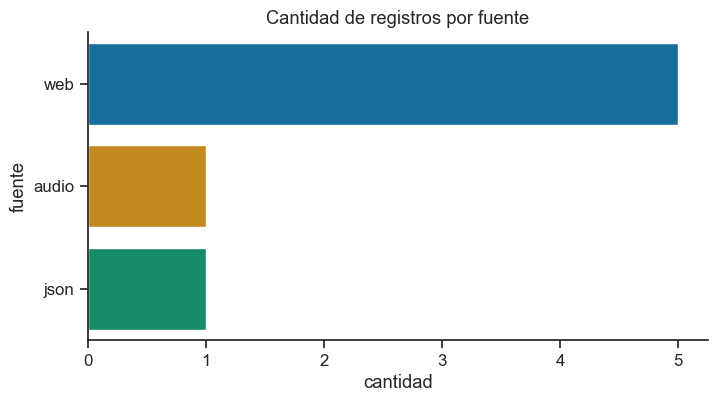

In [96]:
visualizar_origen(df_corpus)

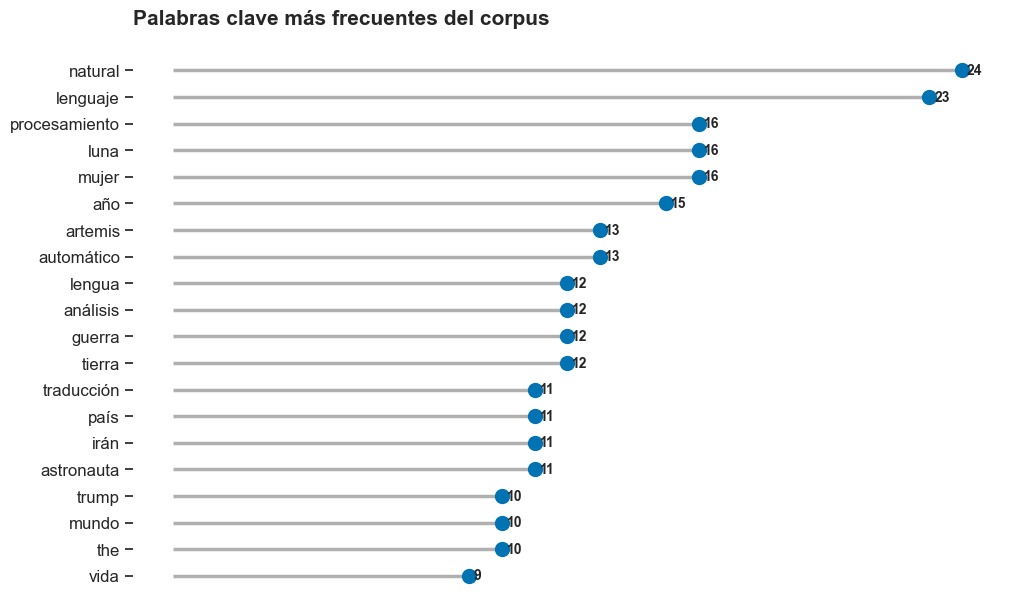

In [98]:
palabras_clave = analizador.extraer_palabras_clave()
visualizar_palabras_clave_lollipop(palabras_clave)

In [100]:
entidades = analizador.extraer_entidades()
fig = visualizar_entidades_plotly(entidades)
fig.show()

> **Pausa de auditoría:**
> Revisá tu visualización. ¿Es accesible? El uso de la paleta 'colorblind' asegura que ciertos grados de daltonismo no impidan la lectura cromática, pero ¿el tamaño de fuente y la proporción de la figura se leen correctamente sin forzar la vista? ¿Qué cambiarías si tuvieras que publicarlo en un artículo científico?

## Parte 4: Pipeline Integrado (Orquestación)

**Objetivo:** Orquestar los componentes desarrollados en un flujo lógico unificado y persistir los hallazgos en formato estructurado. Todo sistema analítico debe poder guardar su estado final de forma estática.

In [104]:
class PipelineMediatico:
    def __init__(self, urls_web=None, url_audio=None, ruta_json=None):
        self.urls_web = urls_web or []
        self.url_audio = url_audio
        self.ruta_json = ruta_json
        self.df = None
        self.analizador = None
        
    def ejecutar_pipeline(self):
        """Orquesta la adquisición, unificación y análisis"""
            # 1. Adquisición de datos
        datos_web = extraer_noticias_web(self.urls_web) if self.urls_web else []
        datos_audio = transcribir_audio_youtube(self.url_audio) if self.url_audio else []
        datos_json = cargar_json_previo(self.ruta_json) if self.ruta_json else []

    # 2. Unificación del corpus
        self.df = unificar_corpus(datos_web, datos_audio, datos_json)

    # 3. Análisis lingüístico
        self.analizador = AnalizadorCorpus(self.df)

        print("Pipeline ejecutado exitosamente.")
        
    def generar_reporte_y_exportar(self, ruta_csv="corpus_resultante.csv", ruta_json="estadisticas.json"):
        """Exporta el dataframe y un JSON analítico"""
        # PASO 3: Persistí self.df como CSV.
        # ¡OJO! La columna 'doc' de spaCy no es serializable, deberías dropearla o extraer sus textos antes de guardar.
        
        # PASO 4: Persistí las estadísticas y el diccionario de entidades devueltas por el Analizador como JSON local.
        df_export = self.df.drop(columns=["doc"], errors="ignore")
        df_export.to_csv(ruta_csv, index=False, encoding="utf-8")

    # PASO 4: Generar estadísticas + entidades
        estadisticas = {
            "total_registros": len(self.df),
            "fuentes": self.df["fuente"].value_counts().to_dict(),
            "entidades": self.analizador.extraer_entidades()
        }

    # Guardar JSON
        with open(ruta_json, "w", encoding="utf-8") as f:
            json.dump(estadisticas, f, indent=4, ensure_ascii=False)

        print(f"CSV guardado en: {ruta_csv}")
        print(f"JSON guardado en: {ruta_json}")

# ---- Espacio para pruebas ----
# pipeline = PipelineMediatico(urls_web=["..."], url_audio="...")
# pipeline.ejecutar_pipeline()
# pipeline.generar_reporte_y_exportar()

> **Pausa de auditoría:**
> Imaginá que un equipo de periodismo de datos de tu facultad te pide el corpus procesado. ¿Qué información necesitaban ellos en el CSV plano versus qué preferiste consolidar en el JSON jerárquico? Pensá por qué separamos esas dos naturalezas de exportación y registralo.

In [103]:
pipeline = PipelineMediatico(
    urls_web=[
        "https://www.bbc.com/mundo",
        "https://elpais.com"
    ],
    url_audio="https://www.youtube.com/watch?v=aqz-KE-bpKQ",
    ruta_json="wikipedia_pln.json"
)

pipeline.ejecutar_pipeline()
pipeline.df.head()

Cargando modelo de lenguaje...
Procesando los textos con spaCy...
Pipeline ejecutado exitosamente.


,fuente,fecha_extraccion,fecha_publicacion,tipo,titulo,texto,origen,doc
0,web,2026-04-11,NaN,noticia,NaN,"BBC News, Mundo - Página de inicio\nPrincipale...",https://www.bbc.com/mundo,"(BBC, News, ,, Mundo, -, Página, de, inicio, \..."
1,web,2026-04-11,NaN,noticia,NaN,Los astronautas de Artemis 2 aterrizan y concl...,https://elpais.com,"(Los, astronautas, de, Artemis, 2, aterrizan, ..."
2,audio,2026-04-11,20141110,transcripcion,Big Buck Bunny 60fps 4K - Official Blender Fou...,El hade ratar un recluzo a la tierra yay AFU<...,https://www.youtube.com/watch?v=aqz-KE-bpKQ,"( , El, hade, ratar, un, recluzo, a, la, tierr..."


In [105]:
pipeline.ejecutar_pipeline()
pipeline.generar_reporte_y_exportar()

Cargando modelo de lenguaje...
Procesando los textos con spaCy...
Pipeline ejecutado exitosamente.


## Parte 5: Dashboard Interactivo con Gradio

**Objetivo:** Diseñar una interfaz interactiva que reaccione dinámicamente frente al usuario, conectando el backend analítico con componentes preconstruidos de frontend.

> [!IMPORTANT]
> **Dilema de diseño**
> ¿Qué componentes elegirías para cada salida? Pedile a la IA tres layouts de estructura (por ejemplo: Pestañas vs. Columna vertical vs. Acordeón) para tu dashboard. Elegí el que consideres mejor para la experiencia de lectura evaluativa y descartá explícitamente los otros dos argumentando tu postura técnica.

**Escribí tu justificación acá:**
(*Tu respuesta...*)

In [108]:
# PASO 1: Diseñá el bloque principal de gr.Blocks() interactuando con los métodos de la clase AnalizadorCorpus.
# Sugerencia: Utilizá pestañas (gr.Tab) para separar "Métricas Generales" de "Filtros e Interacción".

with gr.Blocks(theme=gr.themes.Soft()) as dashboard_medios:
    gr.Markdown("# Explorador de Agenda Mediática")
    
    with gr.Tab("Panorama y Métricas"):
        # Incluí acá la visualización de frecuencias y orígenes, acompañando un gr.DataFrame con métricas generales.
        pass
        
    with gr.Tab("Explorador de Entidades"):
        # Desarrollá un textbox para ingresar una entidad y un botón que dispare
        # un filtrado, mostrando sólo las oraciones dentro de los textos donde se mencionó dicha entidad.
        pass

# Descomentá la siguiente línea cuando el bloque esté terminado
# dashboard_medios.launch()

C:\Users\CynthiaGuzman\AppData\Local\Temp\ipykernel_41556\2256453203.py:4: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as dashboard_medios:


In [109]:
analizador = AnalizadorCorpus(df_corpus)
analizador.extraer_verbos_principales()

Cargando modelo de lenguaje...
Procesando los textos con spaCy...


[('volver', 6),
 ('basar', 6),
 ('pasar', 5),
 ('convertir', 5),
 ('llevar', 4),
 ('mantener', 4),
 ('advertir', 4),
 ('poner', 4),
 ('viajar', 4),
 ('completar', 3),
 ('llegar', 3),
 ('avanzar', 3),
 ('dejar', 3),
 ('demostrar', 3),
 ('resolver', 3)]

In [110]:
def extraer_palabras_clave(self, n=20):
    from collections import Counter

    palabras = []

    for doc in self.df["doc"]:
        for token in doc:
            if token.pos_ in ["NOUN", "PROPN", "ADJ"] \
               and not token.is_stop \
               and not token.is_punct \
               and len(token.text) > 2:
                
                palabras.append(token.lemma_.lower())

    return Counter(palabras).most_common(n)

In [111]:
analizador = AnalizadorCorpus(df_corpus)
analizador.extraer_palabras_clave()

Cargando modelo de lenguaje...
Procesando los textos con spaCy...


[('natural', 24),
 ('lenguaje', 23),
 ('luna', 16),
 ('mujer', 16),
 ('procesamiento', 16),
 ('año', 15),
 ('artemis', 13),
 ('automático', 13),
 ('tierra', 12),
 ('guerra', 12),
 ('análisis', 12),
 ('lengua', 12),
 ('astronauta', 11),
 ('irán', 11),
 ('país', 11),
 ('traducción', 11),
 ('mundo', 10),
 ('trump', 10),
 ('the', 10),
 ('vida', 9)]

In [112]:
def extraer_palabras_clave(self, n=20):
    from collections import Counter

    palabras = []

    for doc in self.df["doc"]:
        for token in doc:
            if not token.is_stop and not token.is_punct and token.is_alpha:
                palabras.append(token.lemma_.lower())

    return Counter(palabras).most_common(n)

In [113]:
analizador = AnalizadorCorpus(df_corpus)

df_palabras = pd.DataFrame(
    analizador.extraer_palabras_clave(),
    columns=["palabra", "frecuencia"]
)

df_palabras

Cargando modelo de lenguaje...
Procesando los textos con spaCy...


,palabra,frecuencia
0,natural,24
1,lenguaje,23
2,luna,16
3,mujer,16
4,procesamiento,16
5,año,15
6,artemis,13
7,automático,13
8,tierra,12
9,guerra,12


In [115]:
import pandas as pd

analizador = AnalizadorCorpus(df_corpus)

df_palabras = pd.DataFrame(
    analizador.extraer_palabras_clave(),
    columns=["palabra", "frecuencia"]
)

df_entidades = pd.DataFrame(analizador.extraer_entidades())

df_fuentes = (
    df_corpus["fuente"]
    .value_counts()
    .reset_index()
)
df_fuentes.columns = ["fuente", "cantidad"]

Cargando modelo de lenguaje...
Procesando los textos con spaCy...


In [116]:
def buscar_entidad(entidad):
    entidad = str(entidad).strip().lower()

    if not entidad:
        return pd.DataFrame(columns=df_corpus.columns)

    resultado = df_corpus[
        df_corpus["texto"].fillna("").str.lower().str.contains(entidad, na=False)
    ].copy()

    return resultado

In [117]:
import gradio as gr

with gr.Blocks(theme=gr.themes.Soft()) as dashboard_medios:
    gr.Markdown("# Explorador de Agenda Mediática")
    gr.Markdown("Dashboard interactivo para explorar el corpus, sus métricas y las entidades detectadas.")

    with gr.Tab("Panorama y Métricas"):
        gr.Markdown("## Corpus consolidado")
        tabla_corpus = gr.Dataframe(value=df_corpus, interactive=False)

        gr.Markdown("## Frecuencia por fuente")
        tabla_fuentes = gr.Dataframe(value=df_fuentes, interactive=False)

        gr.Markdown("## Palabras clave")
        tabla_palabras = gr.Dataframe(value=df_palabras, interactive=False)

        gr.Markdown("## Entidades detectadas")
        tabla_entidades = gr.Dataframe(value=df_entidades, interactive=False)

    with gr.Tab("Explorador de Entidades"):
        gr.Markdown("## Buscar entidad en los textos")
        entrada_entidad = gr.Textbox(
            label="Ingresá una entidad o palabra",
            placeholder="Ejemplo: Artemis, BBC, California..."
        )
        boton_buscar = gr.Button("Buscar")
        salida_busqueda = gr.Dataframe(interactive=False)

        boton_buscar.click(
            fn=buscar_entidad,
            inputs=entrada_entidad,
            outputs=salida_busqueda
        )

C:\Users\CynthiaGuzman\AppData\Local\Temp\ipykernel_41556\1679281111.py:3: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as dashboard_medios:


In [119]:
dashboard_medios.launch(share=True, debug=True)

Rerunning server... use `close()` to stop if you need to change `launch()` parameters.
----

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.


Keyboard interruption in main thread... closing server.


---
## Cierre Formal y Checklist de Entrega

1. ¿Corriste el pipeline de principio a fin, comprobando que las funciones se anidan y comparten el DataFrame correctamente?
2. ¿Tu *AI Reflection Log* evidencia que cuestionaste a la IA y al modelo algorítmico, o todas tus celdas dicen "me devolvió un código y lo usé"?
3. ¿Revisaste el impacto visual de los gráficos garantizando que minimizan la "tinta algorítmica" (Data-Ink Ratio)?
4. ¿Justificaste tus decisiones de arquitectura técnica en el código de orquestación y exportación?

Si respondiste positivamente: felicitaciones, completaste el **TPI 1** demostrando un uso constructivo de la IA, asumiendo un rol profesional capaz de dirigir la automatización de forma estratégica e informada.